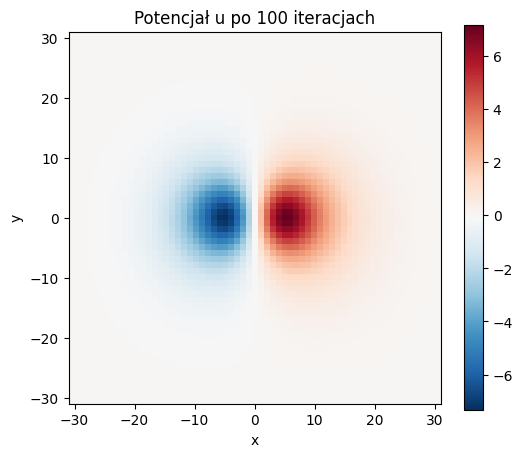

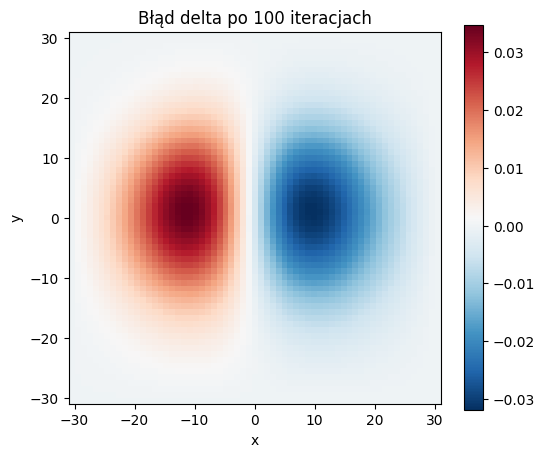

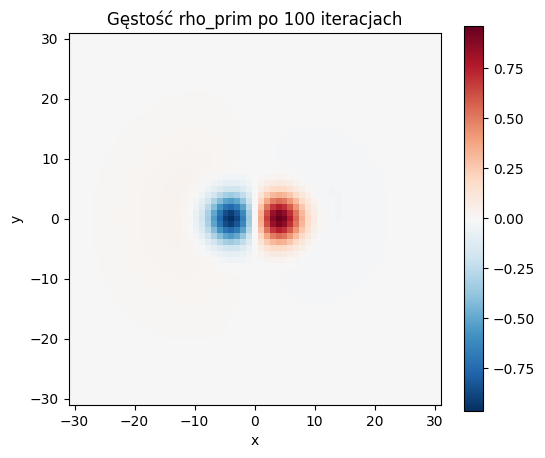

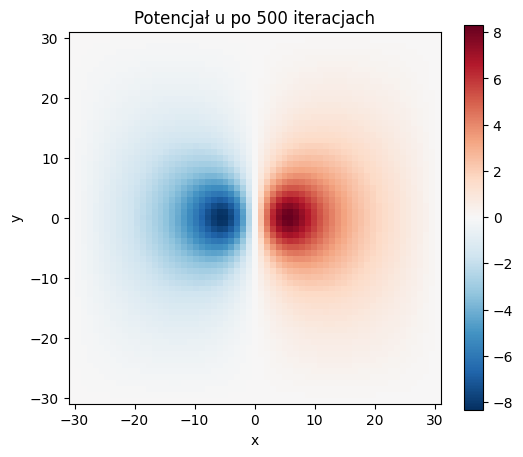

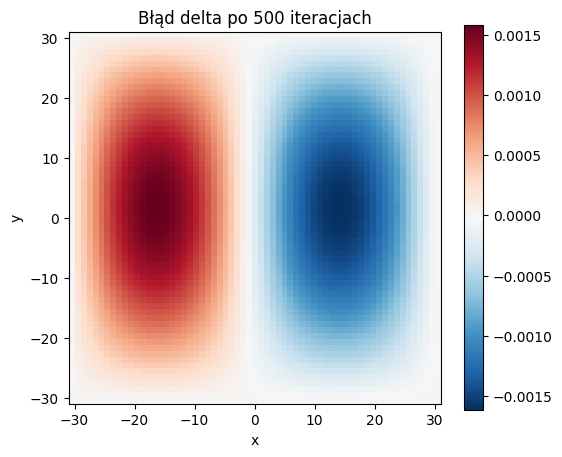

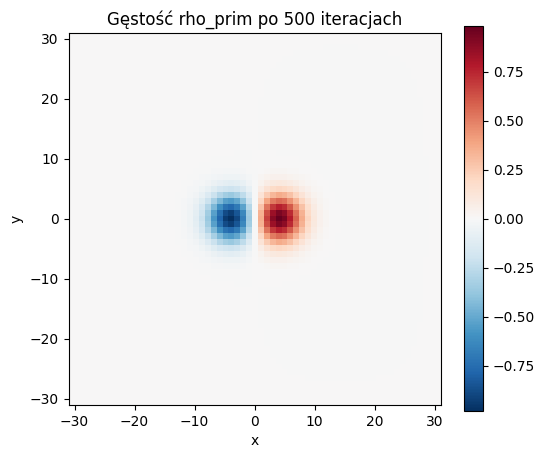

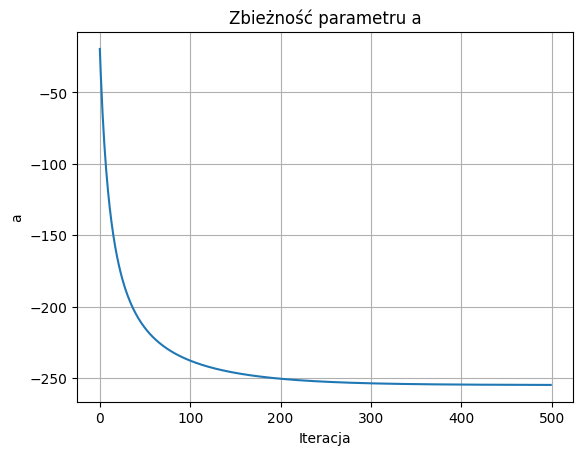

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
d=4
x_0=4
dx=1
N=31
iteracje=500
size=2*N+1
def rho(i,j):
  y=i-N
  x=j-N
  return np.exp(-((x-x_0)**2+y**2)/(d**2))-np.exp(-((x+x_0)**2+y**2)/(d**2))
def plot_map(data, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(data, extent=[-N, N, -N, N], cmap='RdBu_r')
    plt.colorbar()
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()
u=np.zeros((size,size))
rho_tab=np.zeros((size,size))
for i in range(size):
    for j in range(size):
        rho_tab[i,j]=rho(i,j)
a_tab=[]
for it in range(1,iteracje+1):
  a_sum=0
  rho_prim=np.zeros((size,size))
  for i in range(1,size-1):
    for j in range(1,size-1):
      u[i,j]=(u[i+1,j]+u[i-1,j]+u[i,j+1]+u[i,j-1]+rho_tab[i,j]*(dx**2))/4
  laplacian_u=np.zeros_like(u)
  laplacian_u[1:-1,1:-1]=(u[2:,1:-1]+u[:-2,1:-1]+u[1:-1,2:]+u[1:-1,:-2]-4*u[1:-1,1:-1])/(dx**2)
  a=-np.sum(0.5*u[1:-1,1:-1]*laplacian_u[1:-1,1:-1]+rho_tab[1:-1,1:-1]*u[1:-1,1:-1])*(dx**2)
  if it == 100 or it == 500:
    rho_prim=-laplacian_u
    delta=np.zeros_like(rho_tab)
    delta[1:-1,1:-1]=rho_prim[1:-1,1:-1]-rho_tab[1:-1,1:-1]
    plot_map(u,f"Potencjał u po {it} iteracjach")
    plot_map(delta,f"Błąd delta po {it} iteracjach")
    plot_map(rho_prim, f"Gęstość rho_prim po {it} iteracjach")
  a_tab.append(a)
plt.figure()
plt.plot(a_tab)
plt.title("Zbieżność parametru a")
plt.xlabel("Iteracja")
plt.ylabel("a")
plt.grid(True)
plt.show()

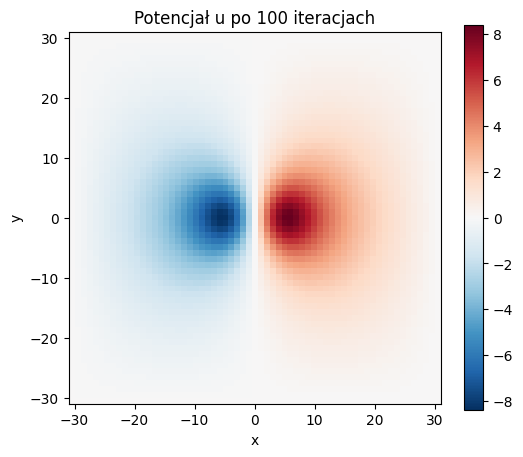

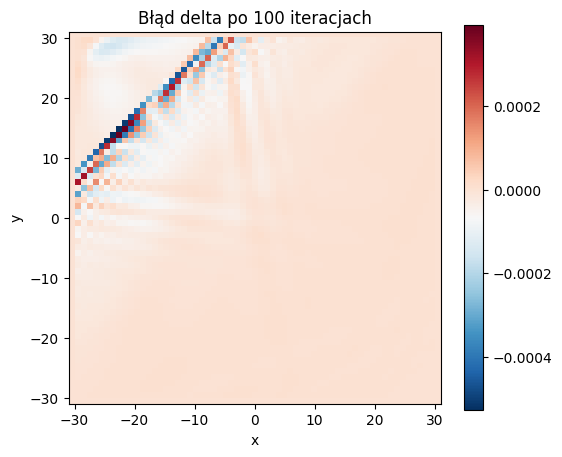

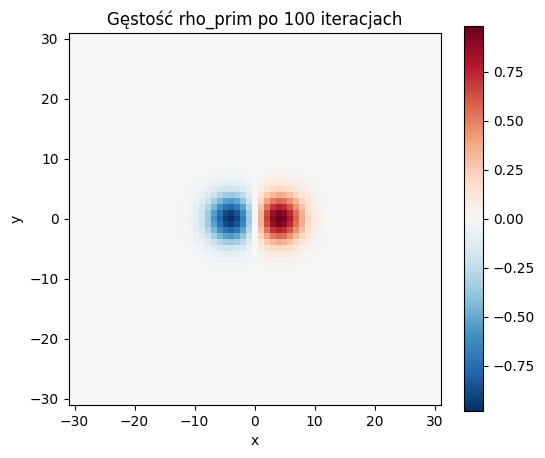

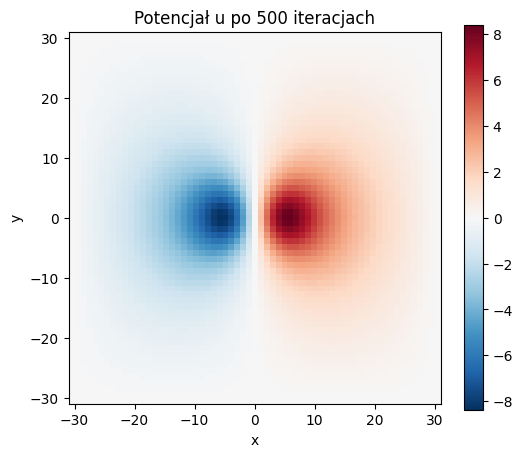

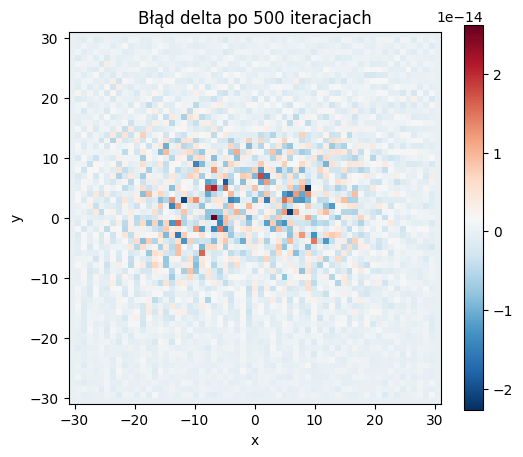

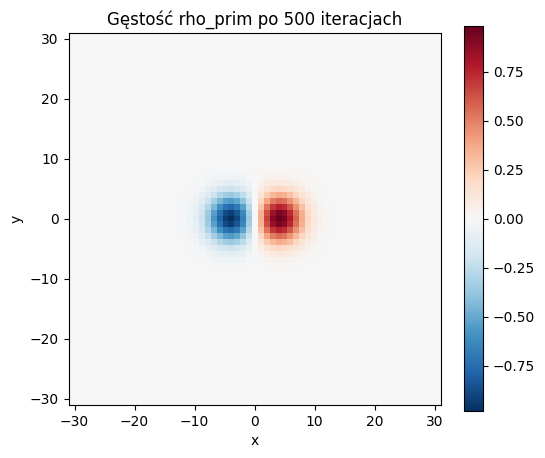

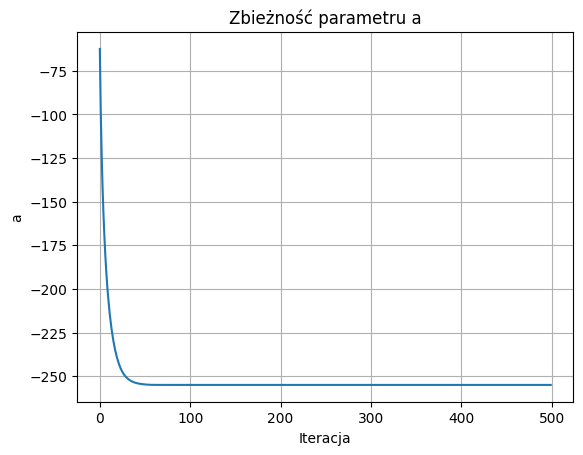

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
d=4
x_0=4
dx=1
N=31
iteracje=500
size=2*N+1
w=1.9
def rho(i,j):
  y=i-N
  x=j-N
  return np.exp(-((x-x_0)**2+y**2)/(d**2))-np.exp(-((x+x_0)**2+y**2)/(d**2))
def plot_map(data, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(data, extent=[-N, N, -N, N], cmap='RdBu_r')
    plt.colorbar()
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()
u=np.zeros((size,size))
rho_tab=np.zeros((size,size))
for i in range(size):
    for j in range(size):
        rho_tab[i,j]=rho(i,j)
a_tab=[]
for it in range(1,iteracje+1):
  a_sum=0
  rho_prim=np.zeros((size,size))
  for i in range(1,size-1):
    for j in range(1,size-1):
      u[i,j]=(1-w)*u[i,j]+w*(u[i+1,j]+u[i-1,j]+u[i,j+1]+u[i,j-1]+rho_tab[i,j]*(dx**2))/4
  laplacian_u=np.zeros_like(u)
  laplacian_u[1:-1,1:-1]=(u[2:,1:-1]+u[:-2,1:-1]+u[1:-1,2:]+u[1:-1,:-2]-4*u[1:-1,1:-1])/(dx**2)
  a=-np.sum(0.5*u[1:-1,1:-1]*laplacian_u[1:-1,1:-1]+rho_tab[1:-1,1:-1]*u[1:-1,1:-1])*(dx**2)
  if it == 100 or it == 500:
    rho_prim=-laplacian_u
    delta=np.zeros_like(rho_tab)
    delta[1:-1,1:-1]=rho_prim[1:-1,1:-1]-rho_tab[1:-1,1:-1]
    plot_map(u,f"Potencjał u po {it} iteracjach")
    plot_map(delta,f"Błąd delta po {it} iteracjach")
    plot_map(rho_prim, f"Gęstość rho_prim po {it} iteracjach")
  a_tab.append(a)
plt.figure()
plt.plot(a_tab)
plt.title("Zbieżność parametru a")
plt.xlabel("Iteracja")
plt.ylabel("a")
plt.grid(True)
plt.show()